# Modeling Customer Churn in Telecommunications Using Machine Learning
### *A case Study of SyriaTel*

# Contents

1. [Introduction](#introduction)
2. [Business Problem](#business-problem)
3. [Data Description](#data-description)
4. 
4. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
5. [Modeling](#Modeling)
6. [Evaluation](#Evaluation)
7. [Conclusion](#Conclusion)

## Introduction

Telecommunications industry connect people, families and businesses every day through calls, messages and internet. Every interaction generates a lot of data, and understanding this data can help companies improve services and keep customers happy. This project aims to explore the data, spot patterns, and even predict what might happen next. One common challenge for telecom companies is customer churn, when people decide to switch to a different service provider. In this project, we use SyriaTel’s customer data to uncover insights and build a model that can help the company identify at-risk customers and take steps to keep them.



## Business Problem
SyriaTel telecommunications company faces the main challenge of customer churn; where customers discontinue their services. Churn affects their revenue directly since acquiring new customers is significantly more expensive than retaining the existing customers. High churn rates reduce long term profitability of the business.
The company needs to understand whether there are predictable patterns in customer behavior that signal an increased likelihood of churn. If these patterns are identified early, SyriaTel can take proactive measures such as targeted promotions, personalized incentives and improved  m m mmm mcustomer care to retain customers with high churn rates. The main goal of this project is to build a binary classification model which accurately predicts customers who are most likely to churn, and identify the features that are important for predicting customer churn.

The objectives of this project are:

1.To Build a logistic regression model that accurately classifies customers as likely to churn or not churn based on historical customer data.

2.To identify key features that influence customer churn.

3.To assess model performance and reliability using appropriate metrics.


## Data Understanding
This project uses SyriaTel’s customer churn dataset, which contains information about their subscribers and whether or not they eventually churned. The data is sourced from Kaggle, a public data repository that hosts a wide range of datasets for research and academic purposes. The dataset is available as a **CSV** file and can be accessed [here](https://www.kaggle.com/datasets/becksddf/churn-in-telecoms-dataset).


In [1]:
#loading the data
import pandas as pd
data = pd.read_csv('Data/Telecom.dataset.csv')
data


,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,AZ,192,415,414-4276,no,yes,36,156.2,77,26.55,...,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
3329,WV,68,415,370-3271,no,no,0,231.1,57,39.29,...,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
3330,RI,28,510,328-8230,no,no,0,180.8,109,30.74,...,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False
3331,CT,184,510,364-6381,yes,no,0,213.8,105,36.35,...,84,13.57,139.2,137,6.26,5.0,10,1.35,2,False


The data is structured with 3333 rows and 21 columns.
The target variable is **Churn**, with two possible outcomes: 

`False` – the customer stayed  
`True` – the customer left the service.

The dataset has several features,**predictors**, that can be widely grouped as: 

- *Customer Identification*:  state, account length, area code, phone number

- *Service Plans*:  international plan, voice mail plan

- *Usage*:  number vmail messages, total day minutes, total day calls, total eve minutes, total eve calls, total night minutes, total night calls, total intl minutes, total intl calls

- *Charges*:  total day charge, total eve charge, total night charge, total intl charge

- *Customer Care*:  customer service calls.



## Data Cleaning


In [2]:
# check for missing values
data.isna().sum()

state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

From the above output, the SyriaTel dataset is complete with no missing values.

In [3]:
 #checking for duplicates 
data.duplicated(subset='phone number').value_counts()

False    3333
dtype: int64

For telecommunications company, every customer has a unique phone number, which can serve as a unique identifier for each record in the dataset. The output above shows that all 3333 rows are unique in the phone number column. Hence there is no duplicates in the dataset.

In [4]:
#summary of the dataframe
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

phone number and state are identifiers or nominal categories that don’t add any predictive value to our model. These features can be dropped to avoid noise in the model.

In [5]:
# Drop identifier columns
data = data.drop(['phone number', 'state'], axis=1)
data.head()


,account length,area code,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,128,415,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,107,415,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,137,415,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,84,408,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,75,415,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## Exploratory data analysis

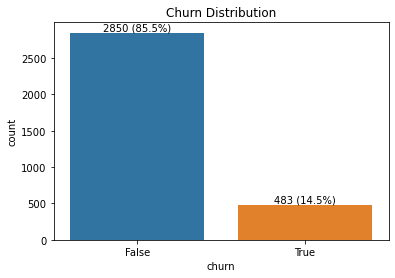

In [6]:
# showing churn Distribution
import seaborn as sns
import matplotlib.pyplot as plt

# Count churn values
churn_counts = data['churn'].value_counts()
churn_percent = data['churn'].value_counts(normalize=True) * 100

# Plot with counts
ax = sns.countplot(x='churn', data=data)

# Annotate with percentages
for p, count, perc in zip(ax.patches, churn_counts, churn_percent):
    ax.annotate(f'{count} ({perc:.1f}%)', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom')

plt.title("Churn Distribution")
plt.show()



The chart shows the distribution of our target variable, Churn. The `False` bar is much taller, representing 85.5% of the records, confirming that most customers stayed. The `True` bar is shorter,14.5%, showing that only a small fraction of customers left. The chart reveals a class imbalance in the dataset. 

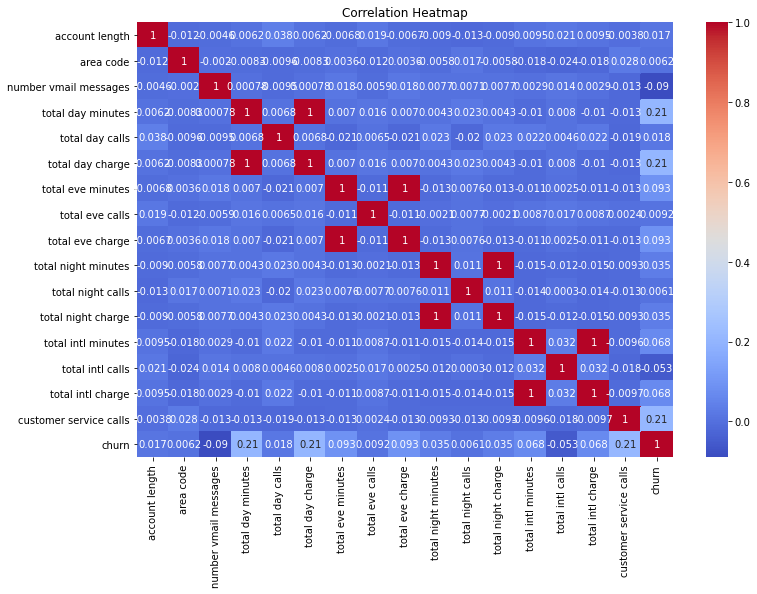

In [7]:
#Checking for multicollinearity
corr = data.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


The correlation heatmap shows pairwise correlation coefficients between numerical variables in the dataset. Total day minutes and total day charge show a perfect correlation of 1. The same is observed for total evening minutes, total night minutes total international minutes and their corresponding charges. This is becauses charges are calculated directly from minutes spent on the call. we shall drop the charges columns to avoid multicollinearity.

In [8]:
# Drop charges columns
data = data.drop(['total day charge', 
                  'total eve charge', 
                  'total night charge', 
                  'total intl charge'], axis=1)
data.head()


,account length,area code,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total eve minutes,total eve calls,total night minutes,total night calls,total intl minutes,total intl calls,customer service calls,churn
0,128,415,no,yes,25,265.1,110,197.4,99,244.7,91,10.0,3,1,False
1,107,415,no,yes,26,161.6,123,195.5,103,254.4,103,13.7,3,1,False
2,137,415,no,no,0,243.4,114,121.2,110,162.6,104,12.2,5,0,False
3,84,408,yes,no,0,299.4,71,61.9,88,196.9,89,6.6,7,2,False
4,75,415,yes,no,0,166.7,113,148.3,122,186.9,121,10.1,3,3,False


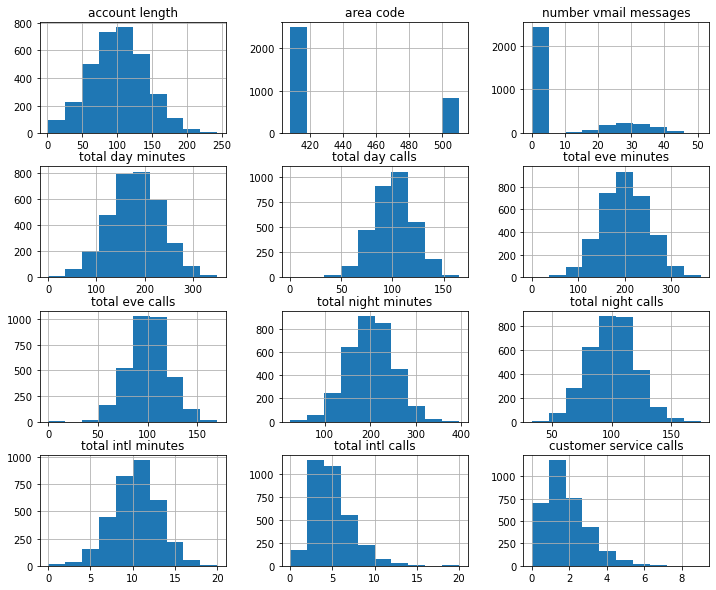

In [9]:
#Distribution of predictor variables
data.drop(columns='churn').hist(figsize=(12,10));


The histogram grid illustrates the distribution of the various numerical variables in the dataset. The variables are measured on different scales and exhibit non-normal (skewed) distributions. The observed variation in scales and the presence of skewed distributions indicate that the data require preprocessing,that is scaling and standardization, before modeling.

## Data Preparation
